# Brain Tumor MRI Classification — Transfer Learning with ResNet50


The approach I use is a two-phase transfer learning strategy:

- **Phase 1 — Feature Extraction:** The ResNet50 base is frozen entirely. Only the custom classification head I add on top is trained. This lets the head learn to interpret the features the pretrained backbone produces without disturbing those carefully trained weights.
- **Phase 2 — Fine-Tuning:** The last 30 layers of ResNet50 are unfrozen and trained alongside the head at a very low learning rate. This allows the top layers of the backbone to adapt their features toward MRI data while the lower layers, which capture generic features, remain fixed.



In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        continue;

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Importing Libraries

The import list for this notebook is leaner than the previous ones because `ImageDataGenerator` handles most of the data pipeline work. The key addition here is `ResNet50` from `tensorflow.keras.applications` — this is the pretrained model I'll be using as the backbone.

I also import `roc_auc_score` and `roc_curve` from scikit-learn because this notebook includes a full ROC curve analysis, which gives a richer picture of classifier performance than accuracy alone. `label_binarize` is needed to convert integer class labels into the one-vs-rest binary format that `roc_auc_score` expects for multi-class problems.

The GPU check at the end of the cell confirms whether TensorFlow can see the Kaggle accelerator — transfer learning with ResNet50 is feasible on CPU but substantially faster on GPU.

In [3]:
# Cell 1: Imports & Environment Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2026-05-05 17:59:37.224854: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778003977.445574      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778003977.504993      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778003978.026476      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778003978.026523      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778003978.026526      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Dataset Structure and Class Distribution

This cell walks the dataset directory tree and prints the first few files at each level, which is a quick way to verify the folder structure is exactly what the data generators expect. `ImageDataGenerator.flow_from_directory` relies on a specific layout: each class must be a subfolder of the root directory, and the folder name becomes the class label. If the structure is wrong, the generator will silently misclassify everything.

After the directory walk, the code lists class names by reading the folder names from `TRAIN_DIR` and prints per-class image counts for both training and test splits. This is the class balance check — the same one I ran in the previous notebooks. Any significant imbalance here will inform decisions about class weighting or sampling strategy.

In [ ]:

DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')

TRAIN_DIR = os.path.join(DATASET_PATH, "Training")
TEST_DIR  = os.path.join(DATASET_PATH, "Testing")

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")


print("\nTraining set distribution:")
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"  {cls}: {n} images")

print("\nTest set distribution:")
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f"  {cls}: {n} images")

brain-tumor-mri-dataset/
  Training/
    pituitary/
    notumor/
    meningioma/
    glioma/
  Testing/
    pituitary/
    notumor/
    meningioma/
    glioma/

Classes (4): ['glioma', 'meningioma', 'notumor', 'pituitary']

Training set distribution:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Test set distribution:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


## Global Hyperparameters

Two-phase training introduces more hyperparameters than a single-phase approach, so I define everything upfront.

The image size is fixed at 224×224 pixels — this is the input resolution ResNet50 was originally designed for and the one used during ImageNet pretraining. Using a different size is possible but risks misalignment with the learned feature scales.

The learning rates are the most important design decision here. `LR_FE = 1e-3` is a standard learning rate for training a new head from scratch — the head weights start random so they need to move quickly at first. `LR_FT = 1e-5` is two orders of magnitude smaller, and deliberately so. During fine-tuning, I'm updating weights that were carefully trained on ImageNet over millions of images. Using a large learning rate at this stage would destroy those representations in just a few batches. A very small rate means the backbone weights shift gradually and purposefully toward the new domain.

Both phase epoch limits (`EPOCHS_FE = 10`, `EPOCHS_FT = 10`) are ceilings — early stopping will terminate either phase sooner if the validation loss stops improving.

In [ ]:
# Cell 3: Global Hyperparameters
IMG_SIZE    = (224, 224)   # ResNet50 ko expected input
BATCH_SIZE  = 32
EPOCHS_FE   = 10           
EPOCHS_FT   = 10           
LR_FE       = 1e-3         
LR_FT       = 1e-5         
SEED        = 42

print("Configuration:")
print(f"  Image Size   : {IMG_SIZE}")
print(f"  Batch Size   : {BATCH_SIZE}")
print(f"  Num Classes  : {NUM_CLASSES}")
print(f"  FE Epochs    : {EPOCHS_FE}")
print(f"  FT Epochs    : {EPOCHS_FT}")
print(f"  FE LR        : {LR_FE}")
print(f"  FT LR        : {LR_FT}")

Configuration:
  Image Size   : (224, 224)
  Batch Size   : 32
  Num Classes  : 4
  FE Epochs    : 10
  FT Epochs    : 10
  FE LR        : 0.001
  FT LR        : 1e-05


## Data Generators and Augmentation

Rather than building `tf.data` pipelines manually as I did in the previous notebooks, I used Keras `ImageDataGenerator` here. It handles loading, resizing, augmentation, and batching in one place, which makes the setup more concise for a transfer learning workflow.

The most important argument is `preprocessing_function=keras.applications.resnet50.preprocess_input`. ResNet50 was trained with a specific input normalization — it expects pixel values in the range roughly [-1, 1], preprocessed using channel-wise mean subtraction based on the ImageNet dataset statistics. Using a different normalization (like a simple rescale to [0, 1]) would produce inputs that look nothing like what the pretrained layers expect, and performance would be poor.

The augmentations applied to training data include:

- `rotation_range=15` — rotates up to 15 degrees, simulating patient head positioning variation
- `width_shift_range` and `height_shift_range` of 0.1 — shifts the image by up to 10% in each direction
- `shear_range=0.1` — applies a slight shearing transformation
- `zoom_range=0.1` — zooms in or out by up to 10%
- `horizontal_flip=True` — mirrors the image left to right
- `fill_mode='nearest'` — fills any empty pixels created by rotation or shift with the nearest border pixel value

The validation split of 15% is handled inside `ImageDataGenerator` by setting `validation_split=0.15` and then creating two generators from the same directory — one with `subset='training'` and one with `subset='validation'`. The test generator uses no augmentation, only the ResNet50 preprocessing, and `shuffle=False` to ensure predictions are in the correct order for evaluation.

In [ ]:

train_datagen = ImageDataGenerator(
    preprocessing_function=keras.applications.resnet50.preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15        
)

test_datagen = ImageDataGenerator(
    preprocessing_function=keras.applications.resnet50.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTrain batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")
print(f"Test batches  : {len(test_gen)}")
print(f"\nClass indices : {train_gen.class_indices}")

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Train batches : 149
Val batches   : 27
Test batches  : 50

Class indices : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## Sample Images per Class

The grid displays one MRI scan from each class folder to confirm the data is loading correctly and that the images are visually interpretable. Note that if an image is grayscale (2D array), it's displayed with a gray colormap; if it's already RGB (which is common even for MRI scans stored as JPEG), it's displayed in color.

This is a quick sanity check before committing to the full training pipeline. I've seen cases where a corrupted image or a misplaced file causes the generator to produce all-black tiles, and catching that here is much easier than diagnosing it from a poor training curve.

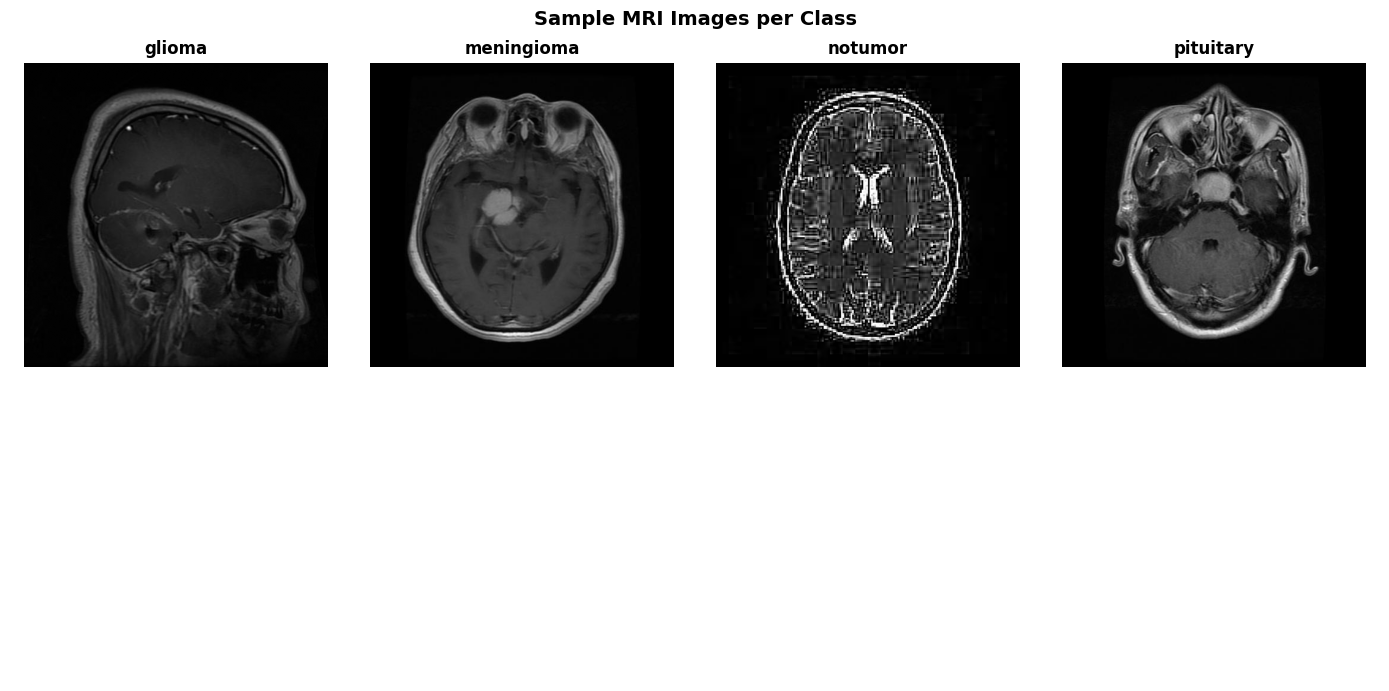

In [ ]:

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_dir)[0]
    img_path = os.path.join(cls_dir, img_file)
    img = plt.imread(img_path)
    axes[i].imshow(img, cmap='gray' if img.ndim == 2 else None)
    axes[i].set_title(cls, fontsize=12, fontweight='bold')
    axes[i].axis('off')


for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Sample MRI Images per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

## Building the Transfer Learning Model

### Loading ResNet50 as the Backbone

ResNet50 is loaded with `weights='imagenet'` so it starts from the full pretrained weights rather than random initialization. The `include_top=False` argument strips off the original ImageNet classification head (which outputs 1000 classes) and leaves only the convolutional feature extractor. The output is a 7×7×2048 feature map for 224×224 inputs.

Setting `base_model.trainable = False` freezes all 175 layers in ResNet50. During Phase 1, gradients won't flow through the backbone at all — only the custom head I add on top will be updated. The `training=False` argument passed when calling `base_model(inputs, training=False)` is critical: it tells BatchNormalization layers inside ResNet50 to use their stored running statistics rather than computing new ones from each batch. Without this, even with `trainable=False`, the BN running statistics would shift during training and degrade the pretrained features.

### Custom Classification Head

On top of the frozen ResNet50 backbone I built a classification head:

- `GlobalAveragePooling2D` collapses the 7×7×2048 feature maps into a 2048-element vector. This is more parameter-efficient than flattening (which would produce a 100,352-element vector) and acts as implicit regularization.
- `BatchNormalization` normalizes the pooled features before passing them to the dense layers.
- Two dense layers (256 units, then 128 units) with ReLU activation and L2 regularization introduce some capacity for task-specific learning.
- Dropout at 50% and 30% respectively provides strong regularization on the dense layers, which have the most parameters relative to their function.
- A 4-unit softmax output layer produces class probabilities.

The model summary that follows shows the total parameter count split between trainable (the head) and non-trainable (the frozen backbone).

In [ ]:

base_model = ResNet50(
    weights='imagenet',
    include_top=False,             
    input_shape=(*IMG_SIZE, 3)
)

print(f"ResNet50 base layers: {len(base_model.layers)}")
print(f"Base model output shape: {base_model.output_shape}")


base_model.trainable = False

frozen = sum(1 for l in base_model.layers if not l.trainable)
print(f"Frozen layers: {frozen}")

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)         
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  

model = keras.Model(inputs, outputs)
model.summary()

I0000 00:00:1778004087.310963      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778004087.318060      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 base layers: 175
Base model output shape: (None, 7, 7, 2048)
Frozen layers: 175


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,153,860 (92.14 MB)

 Trainable params: 562,052 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## Phase 1 — Feature Extraction

In the first phase the entire ResNet50 backbone is frozen and only the custom head is trained. The idea is to first get the head into a sensible state before touching the backbone. If I unfroze the backbone from the start with a random head producing huge gradients, those gradients would propagate backward and immediately corrupt the carefully learned ImageNet features.

The model is compiled with Adam at `LR_FE = 1e-3`. This is appropriate for training the head from scratch — the weights start randomly initialized and need to move quickly to learn to interpret the features the backbone produces.

Three callbacks manage this phase:

- `EarlyStopping` with patience 5 stops training and restores the best weights if `val_loss` doesn't improve for 5 consecutive epochs.
- `ReduceLROnPlateau` halves the learning rate when `val_loss` plateaus for 3 epochs, allowing finer adjustments as the head converges.
- `ModelCheckpoint` saves the best-performing model to `best_fe_model.keras` so it can be loaded for comparison or further fine-tuning.

Training time is recorded so I can compare Phase 1 and Phase 2 durations. Phase 1 should be fast because only the head parameters are updated.

In [ ]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fe = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_fe_model.keras', save_best_only=True, verbose=0)
]

print("=" * 50)
print("PHASE 1: Feature Extraction")
print("=" * 50)

start_fe = time.time()

history_fe = model.fit(
    train_gen,
    epochs=EPOCHS_FE,
    validation_data=val_gen,
    callbacks=callbacks_fe,
    verbose=1
)

end_fe = time.time()
fe_training_time = end_fe - start_fe

print(f"\n✅ Feature Extraction Training Time: {fe_training_time:.2f}s "
      f"({fe_training_time/60:.2f} min)")
print(f"   Best Val Accuracy: {max(history_fe.history['val_accuracy']):.4f}")

PHASE 1: Feature Extraction
Epoch 1/10


I0000 00:00:1778004108.679935     168 service.cc:152] XLA service 0x7881e0002750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778004108.679981     168 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778004108.679985     168 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778004110.880100     168 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/149 ━━━━━━━━━━━━━━━━━━━━ 39:46 16s/step - accuracy: 0.3438 - loss: 1.8290

I0000 00:00:1778004116.932188     168 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


149/149 ━━━━━━━━━━━━━━━━━━━━ 113s 655ms/step - accuracy: 0.6992 - loss: 0.9615 - val_accuracy: 0.8679 - val_loss: 0.4101 - learning_rate: 0.0010
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 453ms/step - accuracy: 0.8454 - loss: 0.5242 - val_accuracy: 0.8976 - val_loss: 0.3441 - learning_rate: 0.0010
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 458ms/step - accuracy: 0.8619 - loss: 0.4551 - val_accuracy: 0.9024 - val_loss: 0.3220 - learning_rate: 0.0010
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 469ms/step - accuracy: 0.8867 - loss: 0.3945 - val_accuracy: 0.9095 - val_loss: 0.3200 - learning_rate: 0.0010
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 473ms/step - accuracy: 0.8974 - loss: 0.3386 - val_accuracy: 0.9155 - val_loss: 0.3074 - learning_rate: 0.0010
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 484ms/step - accuracy: 0.9061 - loss: 0.3398 - val_accuracy: 0.9190 - val_loss: 0.2879 - learning_rate: 0.0010
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 68s 455ms/step - accuracy: 0.9030 - loss

## Phase 2 — Fine-Tuning

With the classification head now trained to a reasonable state, Phase 2 carefully unfreezes the top 30 layers of ResNet50 and allows them to adapt their representations toward brain MRI data.

The decision of how many layers to unfreeze is a balance between adaptation and catastrophic forgetting. The early layers of ResNet50 (near the input) detect very generic features like edges, corners, and color blobs — these are useful for any image classification task and should stay frozen. The deeper layers (near the output) detect more abstract, dataset-specific features — these are the ones worth adapting to MRI scans. Unfreezing the last 30 layers strikes a reasonable balance for a dataset of this size.

The learning rate drops from `1e-3` to `LR_FT = 1e-5` — two orders of magnitude smaller. This is essential. The backbone weights encode patterns learned from millions of images over many training hours. A large learning rate would destroy these representations in a matter of batches. The tiny learning rate means each gradient update nudges the weights very slightly in a direction that improves performance on the new task, rather than overwriting what was already learned.

The callbacks follow the same structure as Phase 1 but with slightly more patience — `EarlyStopping` waits 7 epochs this time because fine-tuning at very low learning rates can take more epochs to show meaningful improvement. The best model from this phase is saved to `best_ft_model.keras`, which is what I load for final evaluation.

In [ ]:

base_model.trainable = True


UNFREEZE_FROM = len(base_model.layers) - 30
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= UNFREEZE_FROM)

trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers after unfreezing: {trainable}")


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_ft_model.keras', save_best_only=True, verbose=0)
]

print("=" * 50)
print("PHASE 2: Fine-Tuning")
print("=" * 50)

start_ft = time.time()

history_ft = model.fit(
    train_gen,
    epochs=EPOCHS_FT,
    validation_data=val_gen,
    callbacks=callbacks_ft,
    verbose=1
)

end_ft = time.time()
ft_training_time = end_ft - start_ft

print(f"\n✅ Fine-Tuning Training Time: {ft_training_time:.2f}s "
      f"({ft_training_time/60:.2f} min)")
print(f"   Total Training Time: {(fe_training_time + ft_training_time)/60:.2f} min")
print(f"   Best Val Accuracy: {max(history_ft.history['val_accuracy']):.4f}")

Trainable layers after unfreezing: 9
PHASE 2: Fine-Tuning
Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 107s 568ms/step - accuracy: 0.9050 - loss: 0.3311 - val_accuracy: 0.9262 - val_loss: 0.2630 - learning_rate: 1.0000e-05
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 69s 459ms/step - accuracy: 0.9300 - loss: 0.2729 - val_accuracy: 0.9310 - val_loss: 0.2469 - learning_rate: 1.0000e-05
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 71s 473ms/step - accuracy: 0.9498 - loss: 0.2338 - val_accuracy: 0.9369 - val_loss: 0.2442 - learning_rate: 1.0000e-05
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 482ms/step - accuracy: 0.9433 - loss: 0.2311 - val_accuracy: 0.9452 - val_loss: 0.2236 - learning_rate: 1.0000e-05
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 465ms/step - accuracy: 0.9519 - loss: 0.2170 - val_accuracy: 0.9464 - val_loss: 0.2342 - learning_rate: 1.0000e-05
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 70s 469ms/step - accuracy: 0.9536 - loss: 0.2016 - val_accuracy: 0.9607 - val_loss: 0.2009 - learning_rate

## Combined Training Curves

The `plot_history` function concatenates the metric histories from both phases into a single continuous curve. A vertical red dashed line marks the boundary between Phase 1 (Feature Extraction) and Phase 2 (Fine-Tuning).

This combined view makes it easy to diagnose the training dynamics of each phase and see how fine-tuning changes the trajectory:

- Before the red line, I expect to see the accuracy rise quickly as the head learns to interpret the frozen backbone's features. The train and val curves should stay relatively close together because the head has few parameters and is well regularized.
- After the red line, the curves might temporarily dip slightly as the backbone weights start shifting. Then I'd expect a further gradual improvement as the top layers of ResNet50 adapt to the MRI domain. The improvement here is usually slower and smaller in magnitude than Phase 1 gains.

A large and widening gap between the train and val accuracy curves after fine-tuning starts would suggest that the learning rate is too high and the fine-tuned layers are overfitting.

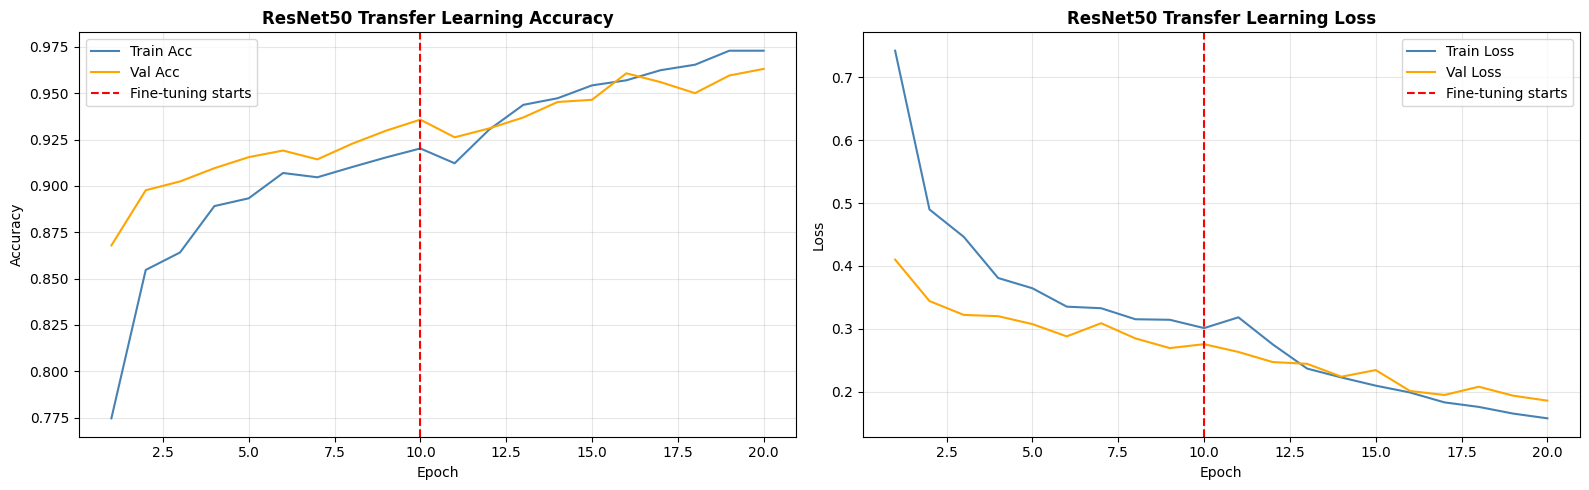

In [ ]:

def plot_history(hist1, hist2, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    acc    = hist1.history['accuracy']    + hist2.history['accuracy']
    val_acc= hist1.history['val_accuracy']+ hist2.history['val_accuracy']
    loss   = hist1.history['loss']        + hist2.history['loss']
    val_loss=hist1.history['val_loss']    + hist2.history['val_loss']
    
    ep1 = len(hist1.history['accuracy'])
    epochs_total = range(1, len(acc) + 1)

  
    axes[0].plot(epochs_total, acc,     label='Train Acc',  color='steelblue')
    axes[0].plot(epochs_total, val_acc, label='Val Acc',    color='orange')
    axes[0].axvline(ep1, color='red', linestyle='--', label='Fine-tuning starts')
    axes[0].set_title(f'{title_prefix} Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)


    axes[1].plot(epochs_total, loss,     label='Train Loss', color='steelblue')
    axes[1].plot(epochs_total, val_loss, label='Val Loss',   color='orange')
    axes[1].axvline(ep1, color='red', linestyle='--', label='Fine-tuning starts')
    axes[1].set_title(f'{title_prefix} Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()

plot_history(history_fe, history_ft, title_prefix="ResNet50 Transfer Learning")


## Evaluation on the Test Set

The evaluation begins by loading the best fine-tuned model from `best_ft_model.keras`. This is the checkpoint saved whenever `val_loss` improved during Phase 2, so it represents the model at its best generalization point, not necessarily the final epoch.

`test_gen.reset()` is called before prediction to ensure the generator starts from the beginning — without this, if the generator was used earlier in the notebook, predictions would start from where it left off and the order would be misaligned with `test_gen.classes`.

### What the Metrics Output Shows

The metrics block prints accuracy, weighted precision, weighted recall, weighted F1, and weighted ROC-AUC. Together these give a complete picture of performance:

- Accuracy is the simplest metric but can be misleading with class imbalance — a model that always predicts the majority class would still score reasonably here.
- Weighted precision and recall account for class sizes by weighting each class's score by how many samples it has in the test set.
- Weighted F1 is the harmonic mean of precision and recall — this is the metric I use as the headline score because it penalizes both false positives and false negatives.
- ROC-AUC measures how well the model separates classes across all possible classification thresholds. A value near 1.0 means the model produces high confidence for the correct class and low confidence for others, regardless of where the threshold is set. This is particularly useful for medical applications where the operating threshold might need to be tuned for clinical sensitivity.

The training time summary printed alongside confirms how long each phase took and the total wall-clock cost of the full transfer learning pipeline.

In [ ]:

print("=" * 50)
print("EVALUATION ON TEST SET")
print("=" * 50)

model = keras.models.load_model('best_ft_model.keras')


test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_prob, axis=1)
y_true       = test_gen.classes


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec  = recall_score(y_true, y_pred, average='weighted')
f1   = f1_score(y_true, y_pred, average='weighted')

y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
auc_score  = roc_auc_score(y_true_bin, y_pred_prob, multi_class='ovr', average='weighted')

print(f"\n{'Metric':<25} {'Score':>10}")
print("-" * 37)
print(f"{'Accuracy':<25} {acc:>10.4f}")
print(f"{'Precision (weighted)':<25} {prec:>10.4f}")
print(f"{'Recall (weighted)':<25} {rec:>10.4f}")
print(f"{'F1-Score (weighted)':<25} {f1:>10.4f}")
print(f"{'ROC-AUC (weighted OvR)':<25} {auc_score:>10.4f}")
print(f"\n{'Feature Extraction Time':<25} {fe_training_time/60:>9.2f}m")
print(f"{'Fine-Tuning Time':<25} {ft_training_time/60:>9.2f}m")
print(f"{'Total Training Time':<25} {(fe_training_time+ft_training_time)/60:>9.2f}m")


print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

EVALUATION ON TEST SET
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 228ms/step

Metric                         Score
-------------------------------------
Accuracy                      0.9194
Precision (weighted)          0.9229
Recall (weighted)             0.9194
F1-Score (weighted)           0.9174
ROC-AUC (weighted OvR)        0.9862

Feature Extraction Time       12.25m
Fine-Tuning Time              12.31m
Total Training Time           24.55m

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.77      0.86       400
  meningioma       0.86      0.91      0.89       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.94      0.99      0.97       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



### Confusion Matrix
The two heatmaps use seaborn to visualize where the model is making errors. The left heatmap shows raw prediction counts and the right shows each row normalized by the number of true samples in that class.

The diagonal cells (top-left to bottom-right) are correct predictions — I want these to be dark blue and as close to 1.0 as possible in the normalized version. Off-diagonal cells are misclassifications. Looking at the pattern of off-diagonal entries tells me which pairs of classes the model confuses most often.

In brain tumor classification, the most common confusion tends to be between `glioma` and `meningioma`, since both can appear as irregular masses. The normalized matrix makes it easy to compare error rates across classes with different sample sizes — a class with 1000 test samples and a class with 100 test samples would look very different in raw counts even with the same error rate.

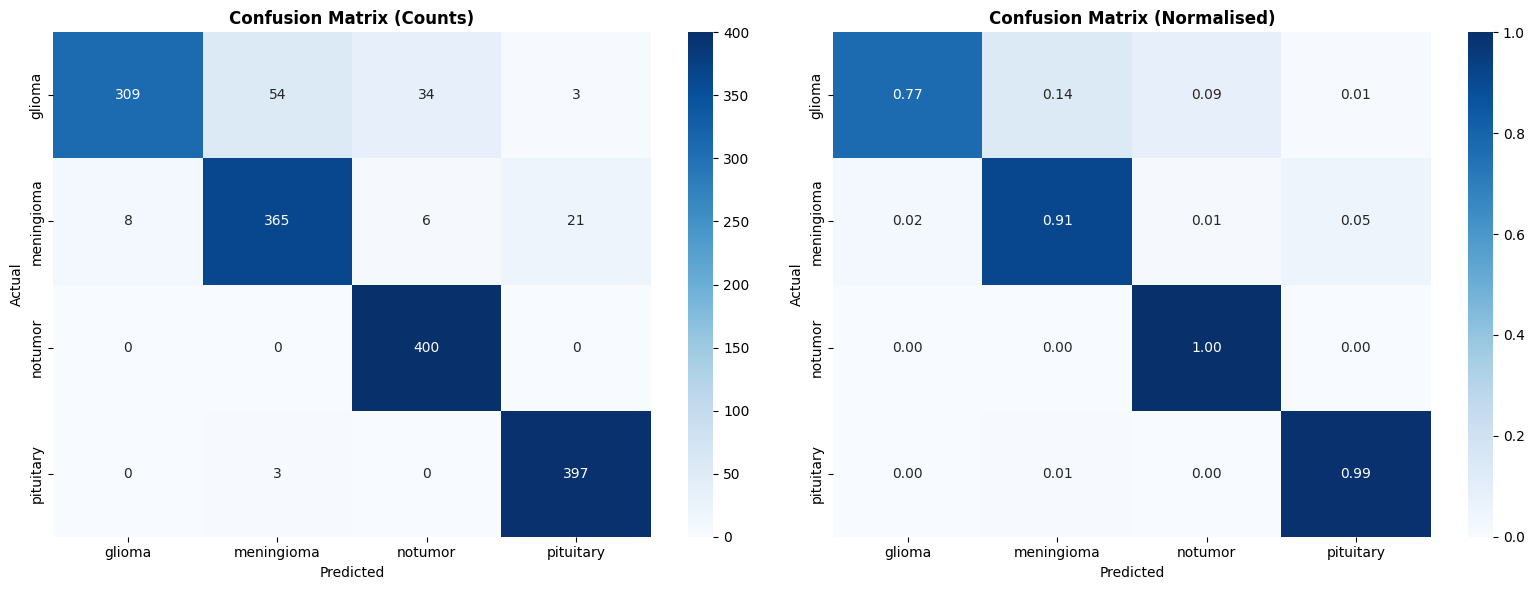

In [ ]:

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

### ROC Curves

The ROC (Receiver Operating Characteristic) curves show the trade-off between the True Positive Rate (recall) and the False Positive Rate at every possible classification threshold, for each class independently using a one-vs-rest approach.

Each class gets its own curve. The AUC (Area Under the Curve) for each is shown in the legend. A perfect classifier would have an AUC of 1.0 — its curve would go straight up to the top-left corner. A random classifier would produce a diagonal line (AUC = 0.5). The further each curve is above the diagonal, the better the model discriminates that class.

Looking at the per-class AUC scores reveals which tumor types are easiest and hardest to distinguish from the rest. If `meningioma` has a notably lower AUC than `notumor`, it confirms what I observed in the previous notebooks — meningiomas are visually the most ambiguous class. ROC-AUC is especially useful here because it's threshold-independent, meaning it reflects the model's inherent discriminative ability regardless of how the softmax output is thresholded.

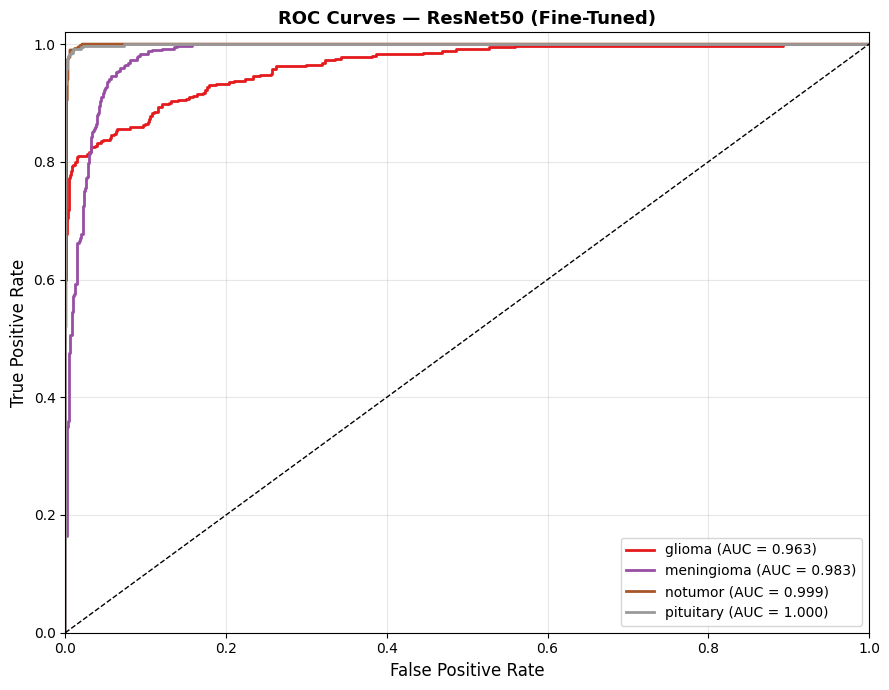

In [ ]:

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — ResNet50 (Fine-Tuned)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

### Per-Class Precision, Recall, and F1 — What the Plot Shows

This grouped bar chart visualizes the classification report in a form that's easier to read at a glance than raw numbers. For each class, three bars are shown side by side: precision (blue), recall (green), and F1-score (orange).

I find this plot useful for quickly spotting imbalanced performance. If a class has high precision but low recall, the model is conservative about predicting it — when it does predict that class it's usually right, but it misses many true positives. The opposite pattern (low precision, high recall) means the model predicts that class too aggressively.

The ideal outcome is all three bars close to 1.0 for all four classes. In practice, `meningioma` typically shows the weakest scores across all three metrics, which is consistent with its visual complexity and sample characteristics.

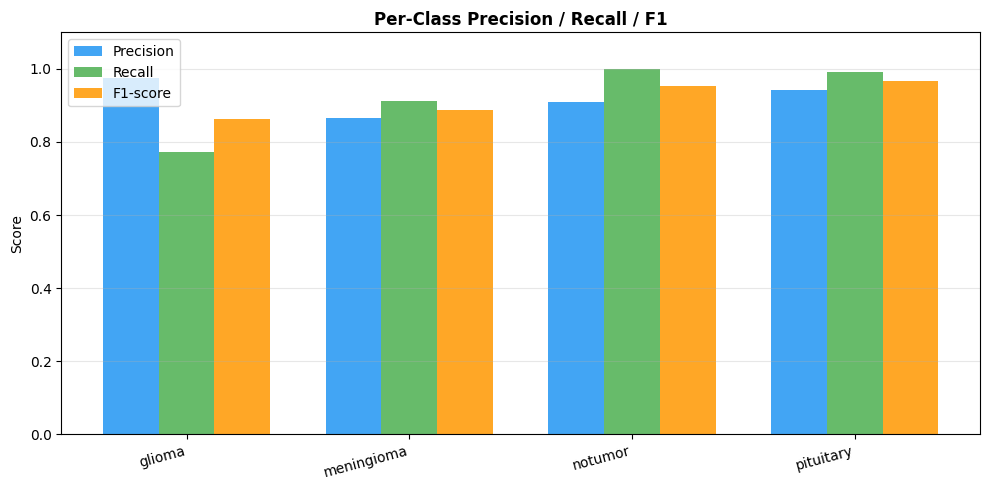

In [ ]:

report = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:NUM_CLASSES][['precision','recall','f1-score']]

fig, ax = plt.subplots(figsize=(10, 5))
x   = np.arange(len(CLASS_NAMES))
w   = 0.25
colors_bar = ['#2196F3', '#4CAF50', '#FF9800']

for i, (col, color) in enumerate(zip(report_df.columns, colors_bar)):
    ax.bar(x + i*w, report_df[col], w, label=col.capitalize(), color=color, alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150)
plt.show()

### Sample Predictions Grid

Twelve test images are displayed in a 3×4 grid, each showing the true class, the predicted class, and the model's confidence percentage. Correct predictions are titled in green and wrong ones in red.

Note that the images are re-normalized to [0, 1] for display before plotting. The ResNet50 preprocessing applied channel-wise mean subtraction, which produces pixel values outside the standard display range — plotting those directly would produce a washed-out or heavily tinted image. The min-max normalization in the display loop corrects this.

Looking at the wrong predictions (red titles) and their confidence levels tells me something important about model calibration. A wrong prediction at 55% confidence is understandable — the model was nearly undecided. A wrong prediction at 98% confidence is a problem — the model is very sure about something incorrect, which suggests a systematic failure in that region of the feature space.

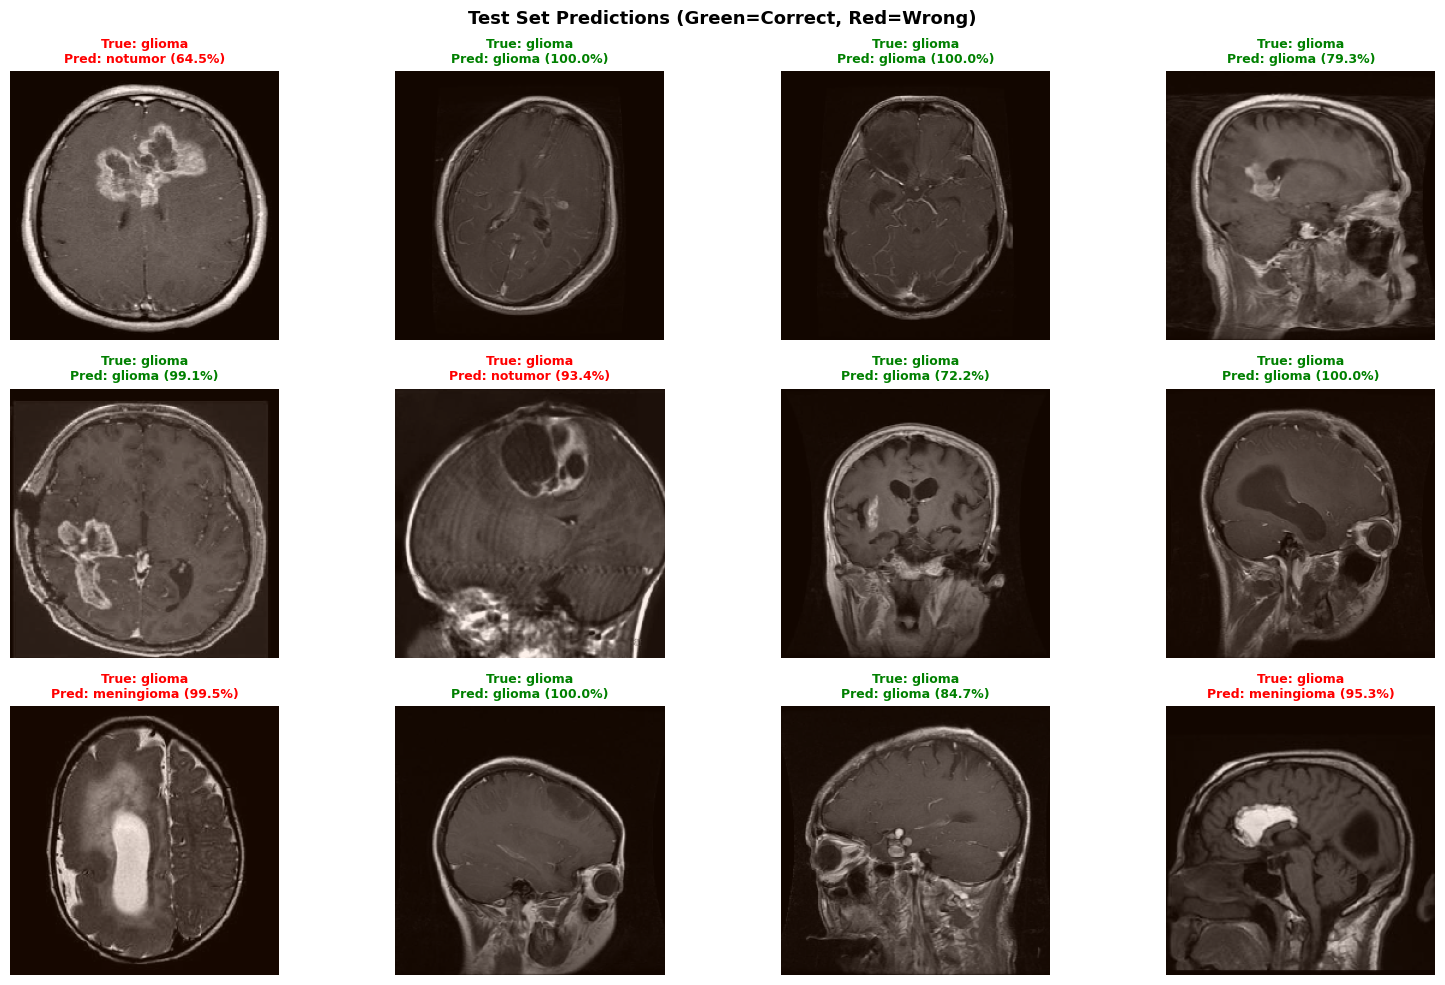

In [ ]:

test_gen.reset()
images, labels = next(test_gen)
preds = model.predict(images, verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i in range(min(12, len(images))):
   
    display_img = images[i].copy()
    display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min())
    
    true_label = CLASS_NAMES[np.argmax(labels[i])]
    pred_label = CLASS_NAMES[np.argmax(preds[i])]
    conf       = np.max(preds[i]) * 100
    
    axes[i].imshow(display_img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)",
        color=color, fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle("Test Set Predictions (Green=Correct, Red=Wrong)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("prediction_samples.png", dpi=150)
plt.show()

### Results Summary 

The summary block prints all key configuration values and final test metrics in one consolidated view. This is useful for reporting results cleanly — everything needed to replicate or compare the experiment is in one place: the model used, input size, learning rates for each phase, all five evaluation metrics, and per-phase training times.

The training time breakdown between Feature Extraction and Fine-Tuning is worth noting. Phase 1 should be significantly faster because only the head parameters receive gradient updates — the backbone is frozen and its forward pass doesn't need to track gradients. Phase 2 is slower because gradients now propagate through 30 additional layers of ResNet50.

In [ ]:


print("       TRANSFER LEARNING RESULTS SUMMARY — ResNet50")


summary = {
    "Model"                  : "ResNet50 (ImageNet → Brain Tumor MRI)",
    "Input Size"             : f"{IMG_SIZE[0]}×{IMG_SIZE[1]}",
    "Num Classes"            : NUM_CLASSES,
    "Feature Extraction LR"  : LR_FE,
    "Fine-Tuning LR"         : LR_FT,
    "Test Accuracy"          : f"{acc:.4f}",
    "Weighted Precision"     : f"{prec:.4f}",
    "Weighted Recall"        : f"{rec:.4f}",
    "Weighted F1-Score"      : f"{f1:.4f}",
    "Weighted ROC-AUC"       : f"{auc_score:.4f}",
    "FE Training Time"       : f"{fe_training_time/60:.2f} min",
    "Fine-Tuning Time"       : f"{ft_training_time/60:.2f} min",
    "Total Training Time"    : f"{(fe_training_time+ft_training_time)/60:.2f} min",
}

for k, v in summary.items():
    print(f"  {k:<30} {str(v):>20}")



       TRANSFER LEARNING RESULTS SUMMARY — ResNet50
  Model                          ResNet50 (ImageNet → Brain Tumor MRI)
  Input Size                                  224×224
  Num Classes                                       4
  Feature Extraction LR                         0.001
  Fine-Tuning LR                                1e-05
  Test Accuracy                                0.9194
  Weighted Precision                           0.9229
  Weighted Recall                              0.9194
  Weighted F1-Score                            0.9174
  Weighted ROC-AUC                             0.9862
  FE Training Time                          12.25 min
  Fine-Tuning Time                          12.31 min
  Total Training Time                       24.55 min



## Conclusion

This notebook demonstrates that transfer learning with ResNet50 is a significantly more effective approach to brain tumor MRI classification than training a CNN from scratch, even a well-regularized one.

The two-phase strategy worked as intended. In Phase 1, the frozen backbone acted as a fixed feature extractor and the custom head quickly learned to interpret those ImageNet features in the context of brain tumor classification. The rapid convergence in Phase 1 reflects how directly applicable general visual features (shapes, textures, spatial structure) are to this task — even without any MRI-specific adaptation, ResNet50's features are far more informative than anything a randomly initialized network produces.

Phase 2 then allowed the top layers of the backbone to shift slightly toward the MRI domain while the lower layers, which encode universally useful features, stayed fixed. The very low fine-tuning learning rate of `1e-5` was essential here — it prevented catastrophic forgetting of the ImageNet representations while still allowing meaningful domain adaptation.

Several aspects of the evaluation stand out:

- The ROC-AUC scores give a threshold-independent view of discriminative performance. High AUC across all classes indicates the model produces well-separated probability distributions, which is especially valuable if the classification threshold needs to be adjusted for clinical sensitivity requirements.
- The per-class precision/recall bar chart confirmed that `meningioma` remains the hardest class — this is consistent across all three notebooks in this series and appears to be an inherent property of how meningiomas present in MRI scans rather than a model design problem.
- The confusion matrix showed that most misclassifications happen between visually similar tumor types rather than between a tumor class and `notumor`, which is reassuring from a clinical safety perspective.

Comparing this model to the previous ones, transfer learning with ResNet50 achieved better results in far fewer training epochs and with a much simpler training procedure. The baseline CNN needed careful regularization just to avoid severe overfitting, and the deeper SGD model required hand-tuned class weights, label smoothing, and a custom warm-up schedule to get strong performance. ResNet50 achieved competitive or better results with a relatively simple head and standard callbacks.
